# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Visualise Camarilla Pivots

In this notebook, we will discuss yet another popular pivot trading system that is known as the Camarilla pivots. The Camarilla pivots help us detect 6 unique levels of support and resistance each. Another interesting point to note about the Camarilla pivots is that these levels tend to appear closer to each other as compared to any other kind of pivots. And this makes it highly suitable for intraday trading.

The notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Import the Data](#data)
3. [Resample the Data](#resample)
4. [Get the Camarilla Pivot](#pivot)
5. [Get the Support and Resistance Levels](#s-r-levels)
6. [Visualise the Camarilla Pivots](#visualise)
7. [Conclusion](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For datetime manipulation
from datetime import timedelta

# For plotting
import matplotlib.pyplot as plt
%matplotlib inline

<a id='data'></a>
## Import the Data

Once again, we will fetch the minute frequency data that is stored within the CSV file `apple_1_minute_2015_2021.csv`. You will find this CSV file in the zip file available in the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the last 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='resample'></a>
## Resample the Data

The calculation for the Camarilla pivot levels will be done on the daily timeframe and further, we will visualise these levels over the minute level data of one trading day. This is because the Camarilla pivots work best when used over shorter timeframes such as the minute-level. Hence, let us begin by resampling the minute level data into the daily frequency.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
             }

# Resample the data to daily frequency
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=16, minutes=0)
data_daily.tail()

,Open,High,Low,Close
2021-02-04 16:00:00+00:00,136.34,137.584,134.59,137.39
2021-02-05 16:00:00+00:00,137.32,139.530,135.86,136.77
2021-02-09 16:00:00+00:00,136.69,137.880,135.00,136.00
2021-02-10 16:00:00+00:00,136.48,136.990,134.40,135.36
2021-02-11 16:00:00+00:00,135.92,136.390,133.57,135.12


<a id='pivot'></a>
## Get the Camarilla Pivot

For Camarilla pivots, the formula to compute the pivot point remains the same as the formula followed for the traditional pivots:

$P = \frac {High + Low + Close}{3}$  

Where, **P** stands for the pivot level. 

In [4]:
# Define the high, low and close of the previous row
prev_high = data_daily['High'].shift(1)
prev_low = data_daily['Low'].shift(1)
prev_close = data_daily['Close'].shift(1)
prev_range = (prev_high - prev_low)

# Calculate the pivot level
data_daily['Pivot'] = (prev_high + prev_low + prev_close)/3
data_daily.tail()

,Open,High,Low,Close,Pivot
2021-02-04 16:00:00+00:00,136.34,137.584,134.59,137.39,133.860000
2021-02-05 16:00:00+00:00,137.32,139.530,135.86,136.77,136.521333
2021-02-09 16:00:00+00:00,136.69,137.880,135.00,136.00,137.386667
2021-02-10 16:00:00+00:00,136.48,136.990,134.40,135.36,136.293333
2021-02-11 16:00:00+00:00,135.92,136.390,133.57,135.12,135.583333


In the above code, we have computed the values of Camarilla pivot level. Now, using the `Pivot` we will calculate the 6 additional support and resistance levels. 

<a id='s-r-levels'></a>
## Get the Support and Resistance Levels

The formulas for computing the support and resistance levels in Camarilla is different. Also note, the resistance levels are referred to as 'H' or 'High' levels and the support levels are referred to as 'L' or 'Low' levels.

Next, let us calculate the Camarilla pivots on the daily data for Apple (stored in `data_daily`) based on the following formula:

* Resistance 1 (H1) = Close + Range * (1.1 / 12)
* Resistance 2 (H2) = Close + Range * (1.1 / 6)
* Resistance 3 (H3) = Close + Range * (1.1 / 4)
* Resistance 4 (H4) = Close + Range * (1.1 / 2)
* Resistance 5 (H5) = Close * (High/Low)
* Resistance 6 (H6) = H5 + 1.168 * (H5 - H4)

Where, Range is the (High - Low) of the preceding candle

In [5]:
# Calculate the Camarilla H/Resistance levels
data_daily['H1'] = prev_close + prev_range * 1.1/12
data_daily['H2'] = prev_close + prev_range * 1.1/6
data_daily['H3'] = prev_close + prev_range * 1.1/4
data_daily['H4'] = prev_close + prev_range * 1.1/2
data_daily['H5'] = prev_close * (prev_high / prev_low)
data_daily['H6'] = data_daily['H5'] + 1.168 * \
    (data_daily['H5'] - data_daily['H4'])

* Support 1 (L1) = Close - Range * (1.1 / 12)
* Support 2 (L2) = Close - Range * (1.1 / 6)
* Support 3 (L3) = Close - Range * (1.1 / 4)
* Support 4 (L4) = Close - Range * (1.1 / 2)
* Support 5 (L5) = Close - (H5 - Close)
* Support 6 (L6) = Close - (H6 - Close)

Where, Range is the (High - Low) of the preceding candle

In [6]:
# Calculate the Camarilla L/Support levels
data_daily['L1'] = prev_close - prev_range * 1.1/12
data_daily['L2'] = prev_close - prev_range * 1.1/6
data_daily['L3'] = prev_close - prev_range * 1.1/4
data_daily['L4'] = prev_close - prev_range * 1.1/2
data_daily['L5'] = prev_close - (data_daily['H5'] - prev_close)
data_daily['L6'] = prev_close - (data_daily['H6'] - prev_close)

# Drop all NaN values from the dataframe
data_daily.dropna(axis=0, how='any', inplace=True)
data_daily.head()

,Open,High,Low,Close,Pivot,H1,H2,H3,H4,H5,H6,L1,L2,L3,L4,L5,L6
2015-01-05 16:00:00+00:00,27.0725,27.1625,26.3525,26.5625,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-06 16:00:00+00:00,26.6700,26.8575,26.1575,26.5575,26.692500,26.636750,26.711000,26.785250,27.008000,27.378955,27.812230,26.488250,26.414000,26.339750,26.117000,25.746045,25.312770
2015-01-07 16:00:00+00:00,26.7950,27.0500,26.6750,26.9375,26.524167,26.621667,26.685833,26.750000,26.942500,27.268204,27.648627,26.493333,26.429167,26.365000,26.172500,25.846796,25.466373
2015-01-08 16:00:00+00:00,27.3075,28.0375,27.1750,27.9675,26.887500,26.971875,27.006250,27.040625,27.143750,27.316190,27.517600,26.903125,26.868750,26.834375,26.731250,26.558810,26.357400
2015-01-09 16:00:00+00:00,28.1675,28.3125,27.5525,28.0000,27.726667,28.046563,28.125625,28.204688,28.441875,28.855153,29.337862,27.888438,27.809375,27.730313,27.493125,27.079847,26.597138


Now that all of the important Camarilla pivot levels have been calculated and stored in the respective columns in dataframe `data_weekly`, we can proceed to visualise the pivots over the data for recent days.

<a id='visualise'></a>
## Visualise the Camarilla Pivots

Let's visualise all of these important levels for the most recent trading date in our data. The levels can be plotted as horizontal lines over the minute close price series data of Apple stock for a recent period.

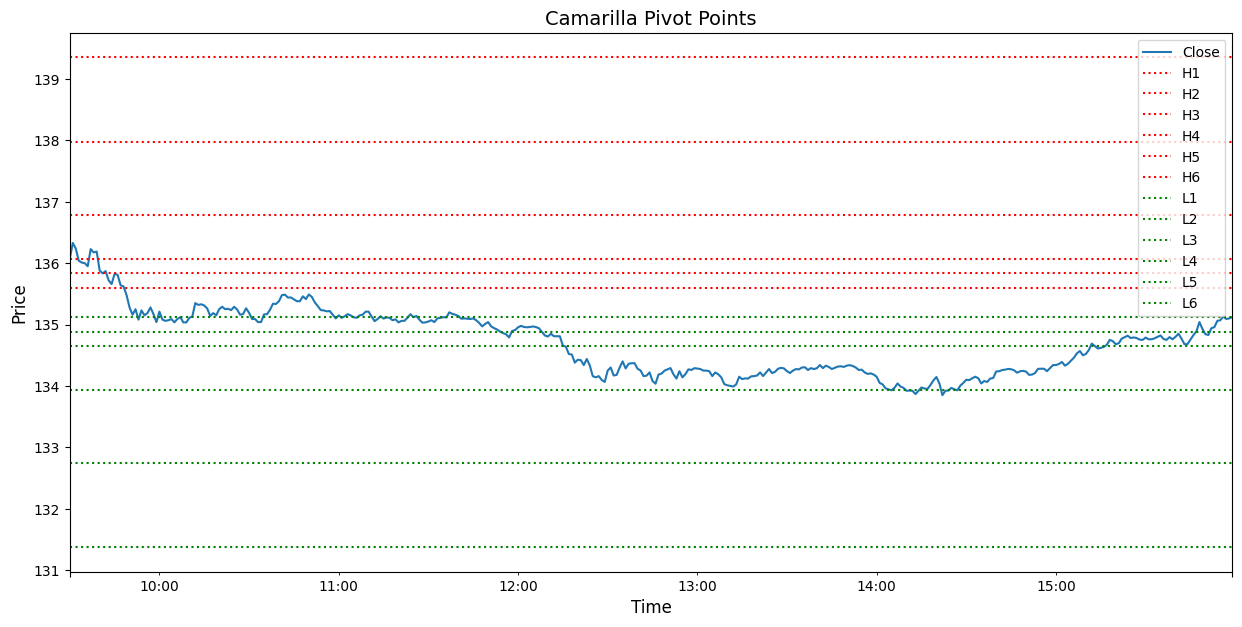

In [7]:
# Plot the close price for the past 5 days
plt.figure(figsize=(15, 7))
data.iloc[-390:]['Close'].plot()

# Plot the resistance levels based on Camarilla
plt.axhline(data_daily.iloc[-1]['H1'], color='r', linestyle=':', label="H1")
plt.axhline(data_daily.iloc[-1]['H2'], color='r', linestyle=':', label="H2")
plt.axhline(data_daily.iloc[-1]['H3'], color='r', linestyle=':', label="H3")
plt.axhline(data_daily.iloc[-1]['H4'], color='r', linestyle=':', label="H4")
plt.axhline(data_daily.iloc[-1]['H5'], color='r', linestyle=':', label="H5")
plt.axhline(data_daily.iloc[-1]['H6'], color='r', linestyle=':', label="H6")

# Plot the resistance levels based on Camarilla
plt.axhline(data_daily.iloc[-1]['L1'], color='g', linestyle=':', label="L1")
plt.axhline(data_daily.iloc[-1]['L2'], color='g', linestyle=':', label="L2")
plt.axhline(data_daily.iloc[-1]['L3'], color='g', linestyle=':', label="L3")
plt.axhline(data_daily.iloc[-1]['L4'], color='g', linestyle=':', label="L4")
plt.axhline(data_daily.iloc[-1]['L5'], color='g', linestyle=':', label="L5")
plt.axhline(data_daily.iloc[-1]['L6'], color='g', linestyle=':', label="L6")

# Set the title and axis label
plt.title('Camarilla Pivot Points', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()

# Show the plot
plt.show()

As you may have observed from the above plot, apart from having additional support and resistance levels, the Camarilla levels seem to appear closer to each other. Especially, when it comes to the initial 3 support and resistance levels.

<a id='conclusion'></a>
## Conclusion

That was all for this notebook. Hopefully, you will now be able to calculate and visualise the various support and resistance levels based on any pivot trading system you desire to choose.

In the upcoming notebook, you will learn to create an interesting trading strategy based on the weekly Woodie's pivots. <br><br>